# Metrics

> Metric tracking and analysis tools

In [ ]:
#| default_exp metrics

In [ ]:
#| hide
from nbdev.showdoc import *

In [ ]:
#| export

# =================================
# Scientific / numerical
# =================================
import numpy as np
from numpy import trapezoid as trapz
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.datasets import load_iris
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import RocCurveDisplay, auc

# =================================
# PyTorch
# =================================
from torch import (
    abs,
    argmax,
    complex64,
    div,
    isnan,
    is_tensor,
    isinf,
    real,
    sigmoid,
    where,
    zeros_like,
)
from torch.fft import fft2, fftshift
from torch.nn.functional import one_hot, softmax

# =================================
# fastai
# =================================
from fastai.metrics import *
from fastai.vision.all import AvgMetric

# =================================
# MONAI
# =================================
from monai.losses import SSIMLoss
from monai.metrics import (
    DiceMetric as _DiceMetric,
    MAEMetric as _MAE,
    MetricsReloadedBinary as _MetricsReloadedBinary,
    MetricsReloadedCategorical as _MetricsReloadedCategorical,
    MultiScaleSSIMMetric as _MS_SSIM,
    PanopticQualityMetric as _PanopticQualityMetric,
    ROCAUCMetric as _ROCAUCMetric,
    PSNRMetric as _PSNR,
    RMSEMetric as _RMSE,
    SSIMMetric as _SSIM,
)

# =================================
# bioMONAI
# =================================
from bioMONAI.core import torch_from_numpy

## Regression metrics

In [ ]:
#| export
def SSIMMetric(spatial_dims=2, **kwargs):
    def SSIM(x, y):
        return _SSIM(spatial_dims, **kwargs)(x,y).mean()
    return AvgMetric(SSIM)

def MSSIMMetric(spatial_dims=2, **kwargs):
    def MSSIM(x, y):
        return _MS_SSIM(spatial_dims, **kwargs)(x,y).mean()
    return AvgMetric(MSSIM)

def MSEMetric(**kwargs):
    def MSE(x, y):
        return _MSE(**kwargs)(x,y).mean()
    return AvgMetric(MSE)

def MAEMetric(**kwargs):
    def MAE(x, y):
        return _MAE(**kwargs)(x,y).mean()
    return AvgMetric(MAE)

def RMSEMetric(**kwargs):
    def RMSE(x, y):
        return _RMSE(**kwargs)(x,y).mean()
    return AvgMetric(RMSE)

def PSNRMetric(max_val, **kwargs):
    def PSNR(x, y):
        return _PSNR(max_val, **kwargs)(x,y).mean()
    return AvgMetric(PSNR)



## Segmentation metrics

In [ ]:
#| export

def DiceMetric(threshold=0.5, instance=False, **kwargs):
    """
    Wrapper around monai.metrics.DiceMetric
    Works for binary segmentation with 1-channel logits.
    Accepts all keyword arguments supported by monai.metrics.DiceMetric
        Example:
            DiceMetric(
                include_background=False,
                reduction="mean",
                get_not_nans=False,
                ignore_empty=True
            )
    """
    dice_metric = _DiceMetric(**kwargs)

    def Dice(pred, target):
        # Check shapes 
        if target.ndim == 3:
            target = target.unsqueeze(1)

        # if target is not binary assume it's an instance mask and
        # convert to a binary foreground/background mask
        if instance:
            # Binarize
            pred = (pred > threshold).float()
            target = (target > 0).float()
        else:
            # logits -> probabilities
            pred = sigmoid(pred)
            # Binarize
            pred = (pred > threshold).float()

        dice_metric.reset()
        dice_metric(pred, target)
        return dice_metric.aggregate()

    return AvgMetric(Dice)


In [ ]:
#| export

def PanopticQualityMetric(**kwargs):
    """
    Wrapper around monai.metrics.PanopticQualityMetric.

    Expects:
        pred  : (B, C, H, W) logits
        target: (B, H, W) or (B, 1, H, W) panoptic map
                Each pixel contains encoded panoptic label
                (semantic + instance id).

    All kwargs are forwarded to MONAI PanopticQualityMetric.
    """
    pq_metric = _PanopticQualityMetric(**kwargs)

    def PQ(pred, target):
        # Convert logits to discrete labels
        # pred = pred.argmax(dim=1)  # (B, H, W)

        if target.ndim == 4 and target.shape[1] == 1:
            target = target.squeeze(1)

        pq_metric.reset()
        pq_metric(y_pred=pred, y=target)
        return pq_metric.aggregate()

    return AvgMetric(PQ)

## Classification Metrics

In [ ]:
#| export

def ROCAUCMetric(num_classes=None, # if not None, checks if preds and targets are one-hot encoded
                 act=None,         # activation operations, typically Sigmoid or Softmax.
                 **kwargs):
    """
    Wrapper around monai.metrics.ROCAUCMetric.

    If num_classes is None:
        assumes pred and target are already one-hot / probability encoded.

    If num_classes is provided:
        automatically one-hot encodes pred/target when needed.
    """
    rocaucmetric = _ROCAUCMetric(**kwargs)

    def _maybe_one_hot(x):
        # already encoded
        if x.ndim > 1 and x.shape[1] == num_classes:
            return x

        return one_hot(x.long(), num_classes=num_classes)

    def ROCAUC(pred, target):
        if act is not None:
            pred = act(pred)

        if num_classes is not None:
            pred = _maybe_one_hot(pred)
            target = _maybe_one_hot(target)

        rocaucmetric.reset()
        rocaucmetric(pred, target)
        return rocaucmetric.aggregate()

    return AvgMetric(ROCAUC)

### ROC Curve

In [ ]:
def plot_roc_curve_with_std(y_probs_folds, y_true_folds, fold_legend_info = False):

    """
    Plot ROC curves with the standard deviation using the probabilities for each fold after applying crossvalidation.

    Parameters:
        y_probs_folds: List of arrays of the predicted probabilities (for the positive class) for each fold.
        y_true_folds: List of arrays of the true labels for each fold.

    """
    true_pos_rates = []
    areas_under_curve = []
    mean_false_pos_rate = np.linspace(0, 1, 100)

    fig, ax = plt.subplots(figsize=(6, 6))

    # Loop to get the ROC curve of each fold
    for fold, (y_probs, y_true) in enumerate(zip(y_probs_folds, y_true_folds)):
        # Calculate the ROC curve for the fold
        calc_ROC = RocCurveDisplay.from_predictions(
            y_true,
            y_probs,
            name=f"ROC fold {fold + 1}",
            alpha=0.3,
            lw=1,
            ax=ax,
        )
        
        if fold_legend_info == False or fold_legend_info == None:
            calc_ROC.line_.set_label('_nolegend_')
        elif fold_legend_info == True:
            pass

        # Interpolate TPR
        interp_tpr = np.interp(mean_false_pos_rate, calc_ROC.fpr, calc_ROC.tpr)
        interp_tpr[0] = 0.0
        true_pos_rates.append(interp_tpr)
        areas_under_curve.append(calc_ROC.roc_auc)


    # Compute mean and standard deviation of the AUC
    mean_tpr = np.mean(true_pos_rates, axis=0)
    mean_tpr[-1] = 1.0
    mean_auc = auc(mean_false_pos_rate, mean_tpr)
    std_auc = np.std(areas_under_curve)

    # Plot the mean ROC curve
    ax.plot(
        mean_false_pos_rate,
        mean_tpr,
        color="r",
        label=r"Mean ROC (AUC = %0.2f %0.2f)" % (mean_auc, std_auc),
        lw=2,
        alpha=0.8,
    )

    # Plot the standard deviation of the true positive rates
    std_tpr = np.std(true_pos_rates, axis=0)
    tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
    tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
    ax.fill_between(
        mean_false_pos_rate,
        tprs_lower,
        tprs_upper,
        color="grey",
        alpha=0.2,
        label=r"1 std. dev.",
    )

    # Add labels and legend
    ax.set(
        xlabel="False Positive Rate",
        ylabel="True Positive Rate",
        title=f"ROC curve with standard deviation",
    )
    ax.legend(loc="lower right")
    plt.show()

##### Example: plot the ROC curve for the data after applying cross-validation and training in order to visualize the standard deviation to compare between splits.

/home/biagio/miniforge3/envs/biomonai_latest/lib/python3.11/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
/home/biagio/miniforge3/envs/biomonai_latest/lib/python3.11/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
/home/biagio/miniforge3/envs/biomonai_latest/lib/python3.11/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
/home/biagio/miniforge3/envs/biomonai_latest/lib/python3.11/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `

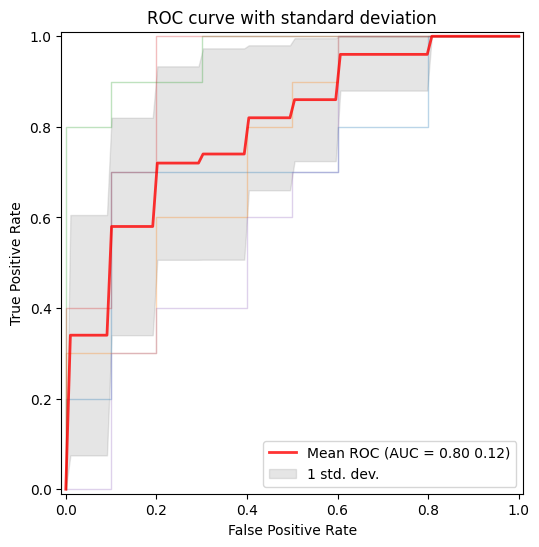

In [ ]:
# For this example the iris dataset is used, but in order to apply it succesfully for binary classification,
# the dataset is reduced to two classes and the features are increased by adding noise.

# Step 1: Data loading and preprocessing
iris = load_iris()
target_names = iris.target_names
X, y = iris.data, iris.target
X, y = X[y != 2], y[y != 2]
n_samples, n_features = X.shape

# Step 2: Adding noise to the data
random_state = np.random.RandomState(0)
X = np.concatenate([X, random_state.randn(n_samples, 300 * n_features)], axis=1)

# Step 3: Application of  cross-validation
cv = StratifiedKFold(n_splits=5)
splits = list(cv.split(X, y))

# Step 4: Training of a SVM algorithm
y_probs_folds = []
y_true_folds = []

classifier = svm.SVC(kernel="linear", probability=True, random_state=random_state)

# Obtaining the probabilities and true labels for each fold
for train_idx, test_idx in splits:
    # Train and predict
    classifier.fit(X[train_idx], y[train_idx])
    y_probs_folds.append(classifier.predict_proba(X[test_idx])[:, 1])  # Probabilities for the positive class
    y_true_folds.append(y[test_idx])  # True labels for the fold

# Call the function to plot the ROC curve with the standard deviation
plot_roc_curve_with_std(y_probs_folds, y_true_folds, fold_legend_info = False)

## Metrics Reloaded

**Metrics Reloaded** is a comprehensive recommendation framework designed to help researchers and practitioners in biomedical image analysis select and apply the most appropriate performance metrics for their specific tasks. Traditional validation practices often rely on a few standard metrics (e.g., Dice score, IoU), which might not always reflect the domain-specific interests or characteristics of a particular problem — such as class imbalance, object size, boundary importance, or task type (classification, segmentation, detection). ([Nature][1])

At its core, Metrics Reloaded introduces the concept of a problem fingerprint: a structured representation of properties relevant to metric selection (e.g., whether the problem is semantic segmentation vs. object detection, the importance of boundary accuracy, class prevalence, etc.). Using the problem fingerprint, the framework **guides users through a systematic decision process** to identify a set of suitable metrics that align with both the task and domain interest. ([Nature][1])

Metrics Reloaded supports a broad range of image analysis tasks, including:

* **Image-level classification**
* **Semantic segmentation**
* **Object detection**
* **Instance segmentation**

To make the selection process more accessible, Metrics Reloaded is also available as an **interactive online tool**, where users can explore the framework’s recommendations and walk through the metric selection process based on their problem fingerprint:
[https://metrics-reloaded.dkfz.de/](https://metrics-reloaded.dkfz.de/) — *Metrics Reloaded online tool* ([metrics-reloaded.dkfz.de][2])

This tool provides a user-centric way to explore metric strengths, weaknesses, and recommendations tailored to different imaging tasks and validation challenges.

[1]: https://www.nature.com/articles/s41592-023-02151-z?utm_source=chatgpt.com "Metrics reloaded: recommendations for image analysis validation | Nature Methods"
[2]: https://metrics-reloaded.dkfz.de/?utm_source=chatgpt.com "Metrics Reloaded"


In [ ]:
#| export
def MetricsReloadedBinary(metric_name, **kwargs):
    "Binary pairwise metrics of MetricsReloaded library"
    def MRB(x, y):
        return _MetricsReloadedBinary(metric_name, **kwargs)(x,y).mean()
    return AvgMetric(MRB)

def MetricsReloadedCategorical(metric_name, **kwargs):
    "Categorical pairwise metrics of MetricsReloaded library"
    def MRC(x, y):
        return _MetricsReloadedCategorical(metric_name, **kwargs)(x,y).mean()
    return AvgMetric(MRC)

## Fourier Ring Correlation

Fourier Ring Correlation (FRC) is a frequency-domain method used to quantify the similarity between two independent measurements of the same underlying signal. It is widely applied in fields such as microscopy, cryo-electron microscopy, and super-resolution imaging to estimate spatial resolution in a statistically robust manner. By comparing corresponding Fourier components over concentric rings (in 2D) or shells (in 3D) of equal spatial frequency, FRC provides a frequency-dependent correlation profile that reflects the reproducibility of structural information.

Mathematically, the Fourier ring correlation at spatial frequency ( r ) is defined as:

$$FRC(r) = \frac{\sum_{k \in r} F_1(k) \overline{F_2(k)}}{\sqrt{\left(\sum_{k \in r} |F_1(k)|^2\right) \left(\sum_{k \in r} |F_2(k)|^2\right)}}$$

where $ F_1(k) $ and $ F_2(k) $ are the Fourier transforms of the two independent images, $ k $ denotes frequency coordinates lying on a ring of radius $ r $, and the overline indicates complex conjugation. The numerator measures cross-correlation of corresponding Fourier coefficients, while the denominator normalizes by their respective spectral energies.

A function that calculates an FRC-based metric determines a resolution criterion by identifying where the FRC curve crosses the predefined threshold at 1/7.

The resulting FRC curve provides a frequency-resolved measure of signal consistency, and the derived cutoff frequency can be converted into a spatial resolution estimate.

#### Radial mask

In [ ]:
#| export

def radial_mask(r,      # Radius of the radial mask
                cx=128, # X coordinate mask center
                cy=128, # Y coordinate maske center
                sx=256, # Size of the x-axis
                sy=256, # Size of the y-axis
                delta=1,# Thickness adjustment for the circular mask
               ):

    """
    Generate a radial mask.

    Returns:
       - numpy.ndarray: Radial mask.
    """
    
    sx = np.arange(0, sx)
    sy = np.arange(0, sy)

    # Calculate squared distances from each point in the grid to the center
    ind = (sx[np.newaxis, :] - cx) ** 2 + (sy[:, np.newaxis] - cy) ** 2

    # Define inner boundary of the circular mask
    ind1 = ind <= ((r[0] + delta) ** 2)

    # Define outer boundary of the circular mask
    ind2 = ind > (r[0] ** 2)

    # Create the radial mask by combining inner and outer boundaries
    return ind1 * ind2


In [ ]:
#| export

def get_radial_masks(width, # Width of the image
                     height, # Height of the image
                     ):

    """
    Generates a set of radial masks and corresponding to spatial frequencies.

    Returns:
        tuple: A tuple containing:
            - numpy.ndarray: Array of radial masks.
            - numpy.ndarray: Array of spatial frequencies corresponding to the masks.
    """

    # Calculate Nyquist frequency
    freq_nyq = int(np.floor(int(min(width, height)) / 2.0))
   
    # Generate radii from 0 to Nyquist frequency
    radii = np.arange(freq_nyq).reshape(freq_nyq, 1)

    # Generate radial masks using the radial_mask function    
    radial_masks = np.apply_along_axis(radial_mask, 1, radii, width//2, height//2, width, height, 1)

    # Calculate spatial frequencies
    spatial_freq = radii.astype(np.float32) / freq_nyq
    spatial_freq = spatial_freq / max(spatial_freq)
    spatial_freq = spatial_freq.squeeze(1)

    return radial_masks, spatial_freq


#### Fourier ring correlation

In [ ]:
#| export
def get_fourier_ring_correlations(image1, # First input image
                                  image2, # Second input image
                                  ):
  
    """
    Compute Fourier Ring Correlation (FRC) between two images.

    Returns:
        tuple: A tuple containing:
            - torch.Tensor: Fourier Ring Correlation values.
            - torch.Tensor: Array of spatial frequencies.
    """
    

    # Get image height and width
    height = image1.shape[len(image1.shape)-1]
    width = image1.shape[len(image1.shape)-2]
    
    # Get set of radial masks, spatial frequency, and Nyquist frequency
    radial_masks, spatial_frequency = get_radial_masks(height,width)

    # Get Nyquist frequency
    freq_nyq = len(spatial_frequency)
    
    # Transform tensor to complex
    image1 = image1.to(complex64)
    image2 = image2.to(complex64)

    # Transofrm array dimensions to (freq_nyq, width. height)
    image1 = image1.unsqueeze(0).repeat(freq_nyq, 1, 1)
    image2 = image2.unsqueeze(0).repeat(freq_nyq, 1, 1)

    # Convert spatial frequency and radial masks to torch.tensor
    spatial_frequency = torch_from_numpy(spatial_frequency)
    radial_masks = torch_from_numpy(radial_masks)

    # Transform tensor to complex
    radial_masks = radial_masks.to(complex64)
         
    # Compute fourier transform
    fft_image1 = fftshift(fft2(image1))
    fft_image2 = fftshift(fft2(image2))

    # Get elements only in the ring
    t1 = fft_image1 * radial_masks
    t2 = fft_image2 * radial_masks
        
    # image2 to complex conjugate
    t2_conj = t2.conj()

    # Numerator
    numerator = abs(real((t1 * t2_conj).sum(dim=(1,2))))

    # Denominator    
    denominator_1 = ((abs(t1) * abs(t1)).sum(dim=(1,2)))
    denominator_2 = ((abs(t2) * abs(t2)).sum(dim=(1,2)))     
    denominator = sqrt(denominator_1 * denominator_2)
   
    # Fourier shell correlation
    FRC = div(numerator, denominator)

    # Remove possible inf and NaN.
    FRC = where(isinf(FRC), zeros_like(FRC), FRC)  # inf
    FRC = where(isnan(FRC), zeros_like(FRC), FRC)  # NaN

    return FRC , spatial_frequency

In [ ]:
#| export

def FRCMetric(image1, # First input image
              image2, # Second input image
              ):


    """
    Compute the area under the Fourier Ring Correlation (FRC) curve between two images.

    Returns:
        - float: The area under the FRC curve.
    """

    # Calculate the Fourier Ring Correlation and spatial frequency
    FRC, spatial_frequency = get_fourier_ring_correlations(image1, image2)

    # Convert to numpy
    FRC = FRC.numpy()
    spatial_frequency = spatial_frequency.numpy()
      
    # Compute the area under the curve using trapezoidal integration
    area = trapz(FRC, spatial_frequency)
    
    return area


---

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()